# **Модуль А:** Анализ и предобработка данных

## Подготовка рабочего пространства

### Импортирование библиотек

In [45]:
# для работы с датафреймами
import pandas as pd

# для визуализации результатов
import matplotlib.pyplot as plt

# для работы с массивами
import numpy as np

# для преобразования текста
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import sent_tokenize

# для работы со строками
import string

# вспомогательные функции
from function import *

# для работы с датасетами
from datasets import Dataset, DatasetDict

### Настройка переменных и загрузка дополнительных параметров

In [46]:
# применяем стиль для графиков
plt.style.use('dark_background')

In [47]:
# скачиваем стоп-слова для русского языка
nltk.download('stopwords')
stop_words = set(stopwords.words('russian'))

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\user1\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


### Вспомогательные функции

Все функции реализованны в файле `function.py`

```py
# функция для чистки стоп слов
def clean_text(text: str, stop_words: set):
    '''
    Функция для чистки текста от стоп слов
        Args:
            - test (str): текст, который нужно почистить от стоп слов
            - stop_words (set): множество стоп слов
        Returns:
            - отфильтрованный текст (str)
    '''
    # создаем список слов используя split()
    words = text.split()
    # фильтруем слова используя заданное множество
    filtered_words = [word for word in words if word.lower() not in stop_words]
    # возвращаем почищенный текст
    return ' '.join(filtered_words)
```

```py
# функция для преобразования формата датасета 
def reorganize_dataset(dataset_path: str):
    '''
    Функция, преобразующая папки в датасет (DataseDict)
    Args:
        - dataset_path (str): путь к папке с данными в строковом формате
    Returns:
        - DatasetDict()
    '''

    # список для всех примеров
    samples = []
    # собираем все примеры
    for folder in os.listdir(dataset_path):
        # путь к папке
        folder_path = os.path.join(dataset_path, folder)
        # проверяем, папка ли это
        if os.path.isdir(folder_path):
            # получаем путь к тексту и аннотации
            text_path = os.path.join(folder_path, 'text.txt')
            annotation_path = os.path.join(folder_path, 'annotation.txt')
            tags_path = os.path.join(folder_path, 'tags.txt')
            

            # проверяем, существуют ли эти файлы
            if os.path.exists(text_path) and os.path.exists(annotation_path):
                # открываем и читаем файл с текстом
                with open(text_path, 'r', encoding='utf-8') as f:
                    text = f.read().strip()

                # открываем и читаем файл с аннотацией
                with open(annotation_path, 'r', encoding='utf-8') as f:
                    summary = f.read().strip()

                # открываем и читаем файл с тэгами
                with open(tags_path, 'r', encoding='utf-8') as f:
                    tag = f.read().strip()
                
                # сохраняем элемент в список
                samples.append({
                    'text_path': text_path,
                    'annotation_path': annotation_path,
                    'tags_path': tags_path,

                    'text': text,
                    'summary': summary,
                    'tag': tag,

                    'text_all_symb': len(text),
                    'summary_all_symb': len(summary),
                    'tag_all_symb': len(tag),

                    'text_clean': len(re.sub(r'[{}]'.format(string.punctuation), '', text)),
                    'summary_clean': len(re.sub(r'[{}]'.format(string.punctuation), '', summary)),
                    'tag_clean': len(re.sub(r'[{}]'.format(string.punctuation), '', tag)),

                    'text_words': len(text.split()),
                    'summary_words': len(summary.split()),
                    'tag_words': len(tag.split()),

                    'id': folder,
                })

    return samples
```

```py
# функция для фильтрации
def df_filter(df: pd.DataFrame, 
              column: str, 
              upper: float = 0.95, 
              lower: float = 0.05):
    '''
    Функция для фильтрации датасета по квартилям
    =======
        **Args**:
            - df (pd.DataFrame): датасет для фильтрации
            - column (str): название колонки
            - upper (float = 0.95) верхний квартиль
            - lower (float = 0.05) нижний квартиль
        **Returns**:
            - filtered_df (pd.DataFrame): отфильтрованный датасет
    
    Пример использования:
    ===

    ```python
    >>  from function import df_filter
    >> 
    >>  for column in df.columns:
    >>      if 'int64' == df[column].dtype:
    >>          filtered_df = df_filter(filtered_df, column)

    ```
    '''
    # верхняя граница
    upper_bound = df[column].quantile(upper)
    # нижняя граница
    lower_bound = df[column].quantile(lower)

    # фильтрую датасет
    filtered_df = df[
        (df[column] >= lower_bound) & (df[column] <=upper_bound)
    ]
    
    # возвращаем отфильтрованный датасет
    return filtered_df.dropna()
```

## Анализ и предобработка данных

В качестве набора данных для решения конкурсного задания, предоставлена папка со следующей архитектурой:

    > Data\DATASET\                        # основная папка с данными
        > 1\                               # папка с названием в виде ее номера
            - annotation.txt               # txt файл с пересказом статьи
            - tags.txt                     # txt файл с тэгами статьи
            - text.txt                     # txt файл со статьей

        > 2\                               # папка с названием в виде ее номера
            - annotation.txt               # txt файл с пересказом статьи
            - tags.txt                     # txt файл с тэгами статьи
            - text.txt                     # txt файл со статьей

        > 3\                               # папка с названием в виде ее номера
        > 4\                               # папка с названием в виде ее номера
        > 5\                               # папка с названием в виде ее номера
        ...
        > 1002\                            # папка с названием в виде ее номера

            

Для начала, нужно назначить путь к основной папке с набором данных, чтобы начать работу с ними:

In [48]:
# путь к основной папке
data_dir = '../Data/DATASET'
# логирование
print(f'Путь существует: {os.path.exists(data_dir)}')
print(f'Кол-во статей в наборе: {len(os.listdir(data_dir))}')

Путь существует: True
Кол-во статей в наборе: 1002


После этого, используя реализованную в файле `function.py` функцию `reorganize_dataset` и модуль `datasets.Dataset`, приведем набор данных в удобный для анализа вид:


In [49]:
# создаем датасет по набору данных
dataset = Dataset.from_list(reorganize_dataset(data_dir))
# выводим структуру датасета
dataset

Dataset({
    features: ['text_path', 'annotation_path', 'tags_path', 'text', 'summary', 'tag', 'text_all_symb', 'summary_all_symb', 'tag_all_symb', 'text_clean', 'summary_clean', 'tag_clean', 'text_words', 'summary_words', 'tag_words', 'id'],
    num_rows: 1002
})

С помощью выше описанной ф-ии, я получил датасет со следующими данными:

*Пути к файлам с текстом, изложением и тэгами:*
- `text_path`
- `annotation_path`
- `tags_path`

*Содержание файлов с текстом, изложением и тэгами*
- `text`
- `summary`
- `tag`

*Кол-во всех символов в файлах*
- `text_all_sumb`
- `summary_all_sumb`
- `tag_all_sumb`

*Кол-во символов в очищенных файлах*
- `text_clean`
- `summary_clean`
- `tag_clean`

*Кол-во всех слов в файлах*
- `text_words`
- `summary_words`
- `tag_words`

*Колонка с id*
- `id`

Для того чтобы легче выводить нужную информацию, я создам датафрейм на основе датасета

In [50]:
# получаю датафрейм в формате pd.DataFrame
df_baseline = pd.DataFrame(dataset)
# вывожу 5 первых строк датафрейма
df_baseline.head()

,text_path,annotation_path,tags_path,text,summary,tag,text_all_symb,summary_all_symb,tag_all_symb,text_clean,summary_clean,tag_clean,text_words,summary_words,tag_words,id
0,../Data/DATASET\1\text.txt,../Data/DATASET\1\annotation.txt,../Data/DATASET\1\tags.txt,Важнейшим вопросом для организации обучения яв...,В электронном учебнике изложены основные разде...,"БАЗА ДАННЫХ, MACROMEDIA FLASH, LIBRARY, ACTION...",5160,379,52,5061,374,49,620,45,6,1
1,../Data/DATASET\10\text.txt,../Data/DATASET\10\annotation.txt,../Data/DATASET\10\tags.txt,Фреймворк - это набор концептуальной структуры...,В этой статье рассматривается Laravel - PHP-фр...,"РАЗРАБОТКА, BACK-END РАЗРАБОТКА, ЗАПРОСЫ, СЕРВ...",6075,212,62,5917,205,58,745,27,6,10
2,../Data/DATASET\100\text.txt,../Data/DATASET\100\annotation.txt,../Data/DATASET\100\tags.txt,В современном мире цифровая трансформация стал...,Тема финансовой кибербезопасности в условиях ц...,"ФИШИНГ, КИБЕРБЕЗОПАСНОСТЬ, ЦИФРОВЫЕ ТЕХНОЛОГИИ...",6692,569,67,6586,564,64,794,69,6,100
3,../Data/DATASET\1000\text.txt,../Data/DATASET\1000\annotation.txt,../Data/DATASET\1000\tags.txt,Разница между ASP.NET и PHP\nASP.NET - это сер...,В статье описана разница между серверной веб-п...,"ASP.NET, PHP, РАЗЛИЧИЯ, DIFFERENCES",5525,172,35,5356,166,31,710,21,4,1000
4,../Data/DATASET\1001\text.txt,../Data/DATASET\1001\annotation.txt,../Data/DATASET\1001\tags.txt,"Всему миру известен данный модный дом, каждая ...","Как появилось имя Коко Шанель? Кто она, создат...","КОКО ШАНЕЛЬ, МОДА XX ВЕКА, ДУХИ CHANEL № 5, МА...",12202,226,68,11905,220,65,1846,35,12,1001


Для наглядности, выведу графики по каждой их колонки, чтобы проверить их разбросы

array([<Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >,
       <Axes: >, <Axes: >, <Axes: >], dtype=object)

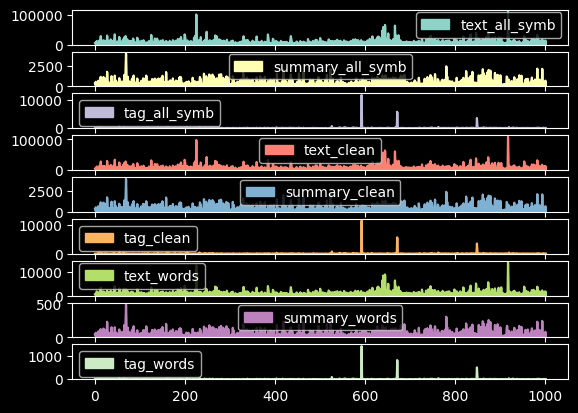

In [51]:
# визуализирую каждую числовую колонку
df_baseline.plot(kind='area', subplots=True)

Можно заметить на графике, что в колонках связанными с `тэгами` есть 3 сильно выраженных столбца (`выбросы`), а также остальные графики выглядят довольно разреженно и `не нормализованно`

In [52]:
# вывожу описание числовых колонок датафрейма
df_baseline.describe()

,text_all_symb,summary_all_symb,tag_all_symb,text_clean,summary_clean,tag_clean,text_words,summary_words,tag_words
count,1002.000000,1002.000000,1002.000000,1002.000000,1002.000000,1002.000000,1002.000000,1002.000000,1002.000000
mean,9243.906188,494.934132,118.254491,8970.108782,485.199601,112.265469,1151.152695,58.764471,12.395210
std,8165.170347,390.030148,426.569564,7920.992738,382.093134,415.891918,1025.736130,46.548680,53.683792
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,5049.000000,243.000000,57.000000,4905.250000,240.000000,53.000000,638.250000,29.000000,6.000000
50%,7259.500000,380.500000,85.000000,7041.000000,374.000000,79.500000,898.500000,45.000000,8.000000
75%,10678.750000,606.000000,120.000000,10412.750000,593.000000,114.000000,1331.000000,72.000000,12.000000
max,111644.000000,4082.000000,11641.000000,108116.000000,4007.000000,11354.000000,14220.000000,488.000000,1405.000000


**Из таблицы выше, можно сделать следующие выводы:**

- в файлах со статьями, изложениями и тегами есть пропуски (`min: 0.00`)
- следует поставить пороговые значения для размера статей и изложенией, так как у статей - `max: 111644` символов, при среднем - `9243` символов; у изложений - `max: 4082` символов, при среднем - `494` символов

Реализую фильтрацию, используя функцию `df_filter` из `function`:


In [53]:
# логирование
print(f'Размер датасета до: {df_baseline.shape}')
# копируем датасет
df_main = df_baseline.copy(deep=True)
# проходимся по каждой колонке в датафрейме
for column in df_main.columns:
    # проверяем тип данных в таблице
    if df_main[column].dtype == 'int64':
        # фильтруем колонку, используя df_filter
        df_main = df_filter(df_main, column)
# логирование
print(f'Размер датасета после: {df_main.shape}')
df_main.head()

Размер датасета до: (1002, 16)
Размер датасета после: (412, 16)


,text_path,annotation_path,tags_path,text,summary,tag,text_all_symb,summary_all_symb,tag_all_symb,text_clean,summary_clean,tag_clean,text_words,summary_words,tag_words,id
0,../Data/DATASET\1\text.txt,../Data/DATASET\1\annotation.txt,../Data/DATASET\1\tags.txt,Важнейшим вопросом для организации обучения яв...,В электронном учебнике изложены основные разде...,"БАЗА ДАННЫХ, MACROMEDIA FLASH, LIBRARY, ACTION...",5160,379,52,5061,374,49,620,45,6,1
1,../Data/DATASET\10\text.txt,../Data/DATASET\10\annotation.txt,../Data/DATASET\10\tags.txt,Фреймворк - это набор концептуальной структуры...,В этой статье рассматривается Laravel - PHP-фр...,"РАЗРАБОТКА, BACK-END РАЗРАБОТКА, ЗАПРОСЫ, СЕРВ...",6075,212,62,5917,205,58,745,27,6,10
2,../Data/DATASET\100\text.txt,../Data/DATASET\100\annotation.txt,../Data/DATASET\100\tags.txt,В современном мире цифровая трансформация стал...,Тема финансовой кибербезопасности в условиях ц...,"ФИШИНГ, КИБЕРБЕЗОПАСНОСТЬ, ЦИФРОВЫЕ ТЕХНОЛОГИИ...",6692,569,67,6586,564,64,794,69,6,100
3,../Data/DATASET\1000\text.txt,../Data/DATASET\1000\annotation.txt,../Data/DATASET\1000\tags.txt,Разница между ASP.NET и PHP\nASP.NET - это сер...,В статье описана разница между серверной веб-п...,"ASP.NET, PHP, РАЗЛИЧИЯ, DIFFERENCES",5525,172,35,5356,166,31,710,21,4,1000
5,../Data/DATASET\1002\text.txt,../Data/DATASET\1002\annotation.txt,../Data/DATASET\1002\tags.txt,При разработке веб-сайта перед любым разработч...,В данной статье представлен метод разработки в...,"ПРОГРАММИРОВАНИЕ, ВЕБ-ПРОГРАММИРОВАНИЕ, БАЗА Д...",6776,301,107,6580,295,99,867,38,11,1002


После этого, еще раз выведу графики по каждой числовой колонке, чтобы увидеть как фильтрация нормализовала мой набор данных:

,text_all_symb,summary_all_symb,tag_all_symb,text_clean,summary_clean,tag_clean,text_words,summary_words,tag_words
count,412.000000,412.000000,412.000000,412.000000,412.000000,412.000000,412.000000,412.000000,412.000000
mean,7569.475728,403.148058,86.716019,7347.720874,395.873786,81.609223,938.662621,47.439320,8.449029
std,2457.748414,158.165133,30.093276,2406.313019,155.269889,28.696842,295.718820,18.649507,2.788545
min,3452.000000,165.000000,32.000000,3352.000000,162.000000,31.000000,490.000000,21.000000,4.000000
25%,5611.750000,281.000000,63.750000,5398.750000,276.500000,59.750000,703.250000,32.000000,6.000000
50%,7237.000000,372.000000,83.000000,6924.500000,366.000000,78.500000,876.000000,44.000000,8.000000
75%,8985.250000,495.000000,108.000000,8774.500000,485.000000,102.000000,1122.500000,58.000000,10.000000
max,15207.000000,924.000000,166.000000,14695.000000,911.000000,153.000000,1726.000000,101.000000,15.000000


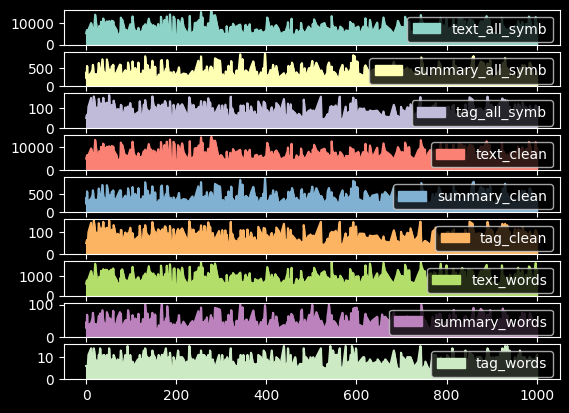

In [54]:
# вывожу график по каждой числовой колонке
df_main.plot(kind='area', subplots=True)
# вывоже описание числовых колонок датафрейма
df_main.describe()

Теперь набор данных нормально распределен, и можно начинать с ним работать

## Предобработка данных

### Лемматизация

In [55]:
from joblib import Parallel, delayed
from multiprocessing import cpu_count
from tqdm import tqdm
from pymystem3 import Mystem

In [56]:
lemm_text = 'Развитие институтов демократии и общегражданской идентичности может сглаживать этнотерриториальную фрагментацию (один из немногих примеров — Швейцария), но последняя не исчезает, и сохраняется вероятность нового роста этнонационализма. Явления этнического федерализма и национально-территориальной автономии, которые могут становится условиями и катализаторами этнонационалистических тенденций, не являются их причинами. Этнонационализм может сформироваться и в государствах, построенных как мононациональные, но имеющих этнотерриториальную фрагментацию. В настоящее время гарантию от этнонационализма не дают ни последовательно реализованные концепции политической нации, ни отрицание коллективных прав этнической общности, ни отрицание этнотерриториальной фрагментации в устройстве государства. Франция, которая не признаёт существования внутри своего государства этнических групп и их прав на автономии, не смогла прекратить баскские, бретонские, прованские и в особенности корсиканские региональные этнонационалистических тенденции. Процессы глобализации привели к ослаблению государств в сфере формирования иерархии идентичностей и потере ими монополии на политическую повестку. Концепцию государства-нации к настоящему времени невозможно считать универсальной формой политической организации социума и пространственной организации власти, о чём свидетельствуют референдумы о независимости Квебека, Шотландии и Каталонии[12].'
mystem = Mystem()

In [95]:
def cleaning(text: str, stop_words: set):
     # создаем список слов используя split()
    words = text.split()
    # фильтруем слова используя заданное множество
    filtered_words = [word for word in words if word.lower() not in stop_words]
    # возвращаем почищенный текст
    return ' '.join(filtered_words)

In [99]:
# функция для лемматизации предложения
def sentence_lemmatize(sentence: str, mystem: Mystem):
    '''Функция для лемматизации текста'''
        
    return ''.join(mystem.lemmatize(sentence.strip()))

# # функция для парралельной лемматизации каждого предложения в тексте
def text_lemmatize(text: str):
    # разбиваем текст на предложения
    sentences = sent_tokenize(text)
    # лемматизируем каждое предложение
    lemmatized = Parallel(n_jobs=-1)\
    (delayed(sentence_lemmatize)(sentence, mystem) for sentence in (sentences))
    
    return cleaning(lemmatized, stop_words)

In [109]:
mystem = Mystem()

def cleaning(text: str, stop_words: set):
    words = text.split()
    filtered_words = [word for word in words if word.lower() not in stop_words]
    return ' '.join(filtered_words)

def sentence_lemmatize(sentence: str):
    '''Функция для лемматизации текста'''
    # Initialize Mystem inside the worker process
    mystem = Mystem()
    return ''.join(mystem.lemmatize(sentence.strip()))

def text_lemmatize(text: str):
    # Split text into sentences
    sentences = sent_tokenize(text)
    # Lemmatize each sentence in parallel
    lemmatized = Parallel(n_jobs=-1)(
        delayed(sentence_lemmatize)(sentence) for sentence in tqdm(sentences)
    )
    # Clean the lemmatized text
    return cleaning(' '.join(lemmatized), stop_words)

In [100]:
test_text = df_main['text'].loc[1]


In [106]:
text_lemmatize(test_text)

'фреймворк - это набор концептуальный структура руководящий принцип, использовать создание что-то полезный. программный среда - это абстракция, который программный обеспечение, обеспечивать общий функциональный возможность, мочь выборочно изменяться помощь дополнительный написать пользователь код, образ предоставлять программный обеспечение конкретный приложе\x02ния. программный среда предоставлять стандартный способ создание развертывание приложение. просто говорить, программный среда - это структура, который мочь использовать созда\x02ния что-либо. позволять использовать различный компонент, взаимодействовать внешний API определять структура ваш приложение. программный фреймворк позволять: \uf0b7 уменьшение сложность разработка - программный среда упрощать работа сложный си\x02туация разбивать разный часть; \uf0b7 чистый код - программный среда помогать писать чистый удобный код; \uf0b7 тестирование отладка - программный среда упрощать тестирование отладка; рекомендация кодирование -

In [108]:
# Объединяем тексты с разделителем "10101011"
combined_text = "10101011".join(df_main['text'])

print(len(combined_text))

3121912


In [113]:
clean_combined = sentence_lemmatize(cleaning(combined_text, stop_words))

In [118]:
processed_texts = clean_combined.split('10101011')

In [119]:
len(processed_texts)

412

In [120]:
df_main['processed_text'] = processed_texts
df_main.head()

,text_path,annotation_path,tags_path,text,summary,tag,text_all_symb,summary_all_symb,tag_all_symb,text_clean,summary_clean,tag_clean,text_words,summary_words,tag_words,id,processed_text
0,../Data/DATASET\1\text.txt,../Data/DATASET\1\annotation.txt,../Data/DATASET\1\tags.txt,Важнейшим вопросом для организации обучения яв...,В электронном учебнике изложены основные разде...,"БАЗА ДАННЫХ, MACROMEDIA FLASH, LIBRARY, ACTION...",5160,379,52,5061,374,49,620,45,6,1,важный вопрос организация обучение являться со...
1,../Data/DATASET\10\text.txt,../Data/DATASET\10\annotation.txt,../Data/DATASET\10\tags.txt,Фреймворк - это набор концептуальной структуры...,В этой статье рассматривается Laravel - PHP-фр...,"РАЗРАБОТКА, BACK-END РАЗРАБОТКА, ЗАПРОСЫ, СЕРВ...",6075,212,62,5917,205,58,745,27,6,10,Фреймворк - это набор концептуальный структура...
2,../Data/DATASET\100\text.txt,../Data/DATASET\100\annotation.txt,../Data/DATASET\100\tags.txt,В современном мире цифровая трансформация стал...,Тема финансовой кибербезопасности в условиях ц...,"ФИШИНГ, КИБЕРБЕЗОПАСНОСТЬ, ЦИФРОВЫЕ ТЕХНОЛОГИИ...",6692,569,67,6586,564,64,794,69,6,100,В современный мир цифровой трансформация стано...
3,../Data/DATASET\1000\text.txt,../Data/DATASET\1000\annotation.txt,../Data/DATASET\1000\tags.txt,Разница между ASP.NET и PHP\nASP.NET - это сер...,В статье описана разница между серверной веб-п...,"ASP.NET, PHP, РАЗЛИЧИЯ, DIFFERENCES",5525,172,35,5356,166,31,710,21,4,1000,Разница ASP.NET PHP ASP.NET - это серверный ве...
5,../Data/DATASET\1002\text.txt,../Data/DATASET\1002\annotation.txt,../Data/DATASET\1002\tags.txt,При разработке веб-сайта перед любым разработч...,В данной статье представлен метод разработки в...,"ПРОГРАММИРОВАНИЕ, ВЕБ-ПРОГРАММИРОВАНИЕ, БАЗА Д...",6776,301,107,6580,295,99,867,38,11,1002,При разработка веб-сайт любой разработчик возн...


Теперь, нужно лемматизировать все статьи из датасета

In [123]:
df_main.to_csv('dataset_info.csv', index=False)

In [124]:
df = pd.read_csv('dataset_info.csv')
df.head()

,text_path,annotation_path,tags_path,text,summary,tag,text_all_symb,summary_all_symb,tag_all_symb,text_clean,summary_clean,tag_clean,text_words,summary_words,tag_words,id,processed_text
0,../Data/DATASET\1\text.txt,../Data/DATASET\1\annotation.txt,../Data/DATASET\1\tags.txt,Важнейшим вопросом для организации обучения яв...,В электронном учебнике изложены основные разде...,"БАЗА ДАННЫХ, MACROMEDIA FLASH, LIBRARY, ACTION...",5160,379,52,5061,374,49,620,45,6,1,важный вопрос организация обучение являться со...
1,../Data/DATASET\10\text.txt,../Data/DATASET\10\annotation.txt,../Data/DATASET\10\tags.txt,Фреймворк - это набор концептуальной структуры...,В этой статье рассматривается Laravel - PHP-фр...,"РАЗРАБОТКА, BACK-END РАЗРАБОТКА, ЗАПРОСЫ, СЕРВ...",6075,212,62,5917,205,58,745,27,6,10,Фреймворк - это набор концептуальный структура...
2,../Data/DATASET\100\text.txt,../Data/DATASET\100\annotation.txt,../Data/DATASET\100\tags.txt,В современном мире цифровая трансформация стал...,Тема финансовой кибербезопасности в условиях ц...,"ФИШИНГ, КИБЕРБЕЗОПАСНОСТЬ, ЦИФРОВЫЕ ТЕХНОЛОГИИ...",6692,569,67,6586,564,64,794,69,6,100,В современный мир цифровой трансформация стано...
3,../Data/DATASET\1000\text.txt,../Data/DATASET\1000\annotation.txt,../Data/DATASET\1000\tags.txt,Разница между ASP.NET и PHP\nASP.NET - это сер...,В статье описана разница между серверной веб-п...,"ASP.NET, PHP, РАЗЛИЧИЯ, DIFFERENCES",5525,172,35,5356,166,31,710,21,4,1000,Разница ASP.NET PHP ASP.NET - это серверный ве...
4,../Data/DATASET\1002\text.txt,../Data/DATASET\1002\annotation.txt,../Data/DATASET\1002\tags.txt,При разработке веб-сайта перед любым разработч...,В данной статье представлен метод разработки в...,"ПРОГРАММИРОВАНИЕ, ВЕБ-ПРОГРАММИРОВАНИЕ, БАЗА Д...",6776,301,107,6580,295,99,867,38,11,1002,При разработка веб-сайт любой разработчик возн...


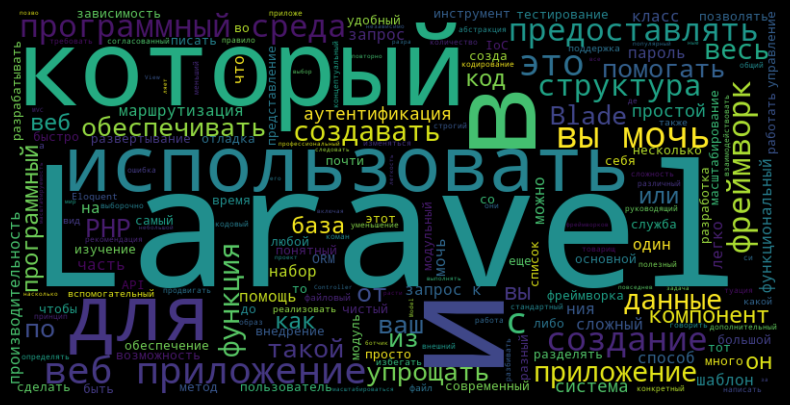

In [22]:
generate_wordcoud(lemmatized_text)

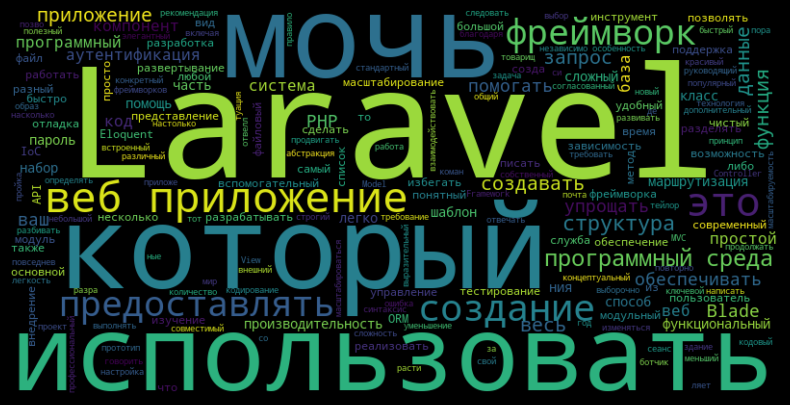

In [23]:
clean_text = clean_text(lemmatized_text, stop_words)
generate_wordcoud(clean_text)

После того как я лемматизировал текста, и удалил из них стоп слова, нужно их токенизировать

In [35]:
from transformers import T5Tokenizer, T5ForConditionalGeneration


model_name = "sarahai/ruT5-base-summarizer"  
tokenizer = T5Tokenizer.from_pretrained(model_name)